## Problem 2: Portfolio Risk Modeling

In this problem, the company manages a portfolio containing two assets, $X_1$ and $X_2$.  
The variables $X_1$ and $X_2$ represent the gain or loss from Asset 1 and Asset 2.

The total portfolio cash flow is defined as:

$$
Y = X_1 + X_2
$$

The main objective is to build a probabilistic joint model for $X_1$ and $X_2$, then use the model to study the expected cash flow and the extreme loss behavior of the portfolio.

<h1>Import Libraries</h1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy import stats
from scipy.stats import norm, lognorm, kendalltau
import warnings
warnings.filterwarnings('ignore')

<h3>Load the data</h3>

In [2]:
data = pd.read_csv("Data_Prob_2.csv")
data.head()

,Asset I [Euro],Asset II [Euro]
0,-20.821808,-41.828532
1,28.693620,49.885652
2,41.109685,49.573606
3,10.574279,6.292043
4,22.386677,42.105657


In [3]:
data.isna().any().sum()

np.int64(0)

In [4]:
print([k for k in data.keys() if not k.startswith('__')])

X1 = data['Asset I [Euro]'].to_numpy().flatten()
X2 = data['Asset II [Euro]'].to_numpy().flatten()

print(f"X1: N={len(X1)}, mean={X1.mean():.4f}, std={X1.std():.4f}")
print(f"X2: N={len(X2)}, mean={X2.mean():.4f}, std={X2.std():.4f}")

['Asset I [Euro]', 'Asset II [Euro]']
X1: N=800, mean=25.9441, std=20.0298
X2: N=800, mean=31.1832, std=24.9916


<h1>Plot the distribution</h1>

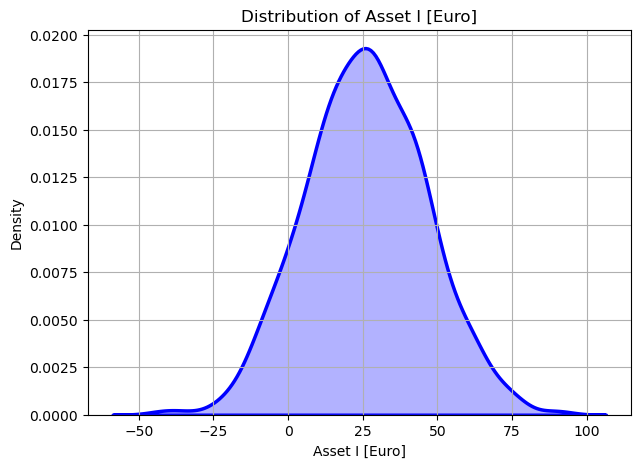

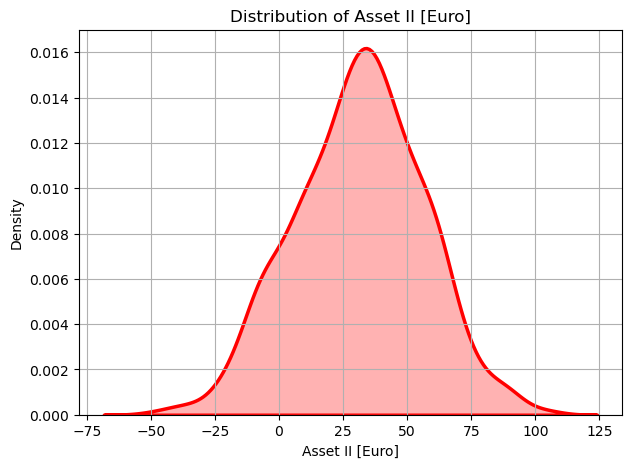

In [5]:
def plot_distribution_curves(data, filename_prefix):
    """
    Plot kernel-density estimates for Sa and EDP.
    Called AFTER fitting so lognormal parameters are already available.
    """
    variables = {
        "Asset I [Euro]": "blue",
        "Asset II [Euro]": "red"
    }
 
    for var, color in variables.items():
        plt.figure(figsize=(7, 5))
 
        sns.kdeplot(
            data=data,
            x=var,
            color=color,
            linewidth=2.5,
            fill=True,
            alpha=0.3
        )
 
        plt.xlabel(var)
        plt.ylabel("Density")
        plt.title(f"Distribution of {var}")
        plt.grid(True)
 
        # Build a safe filename string from the column label
        safe = (
            var.replace("[", "")
               .replace("]", "")
               .replace("/", "_")
               .replace("^", "")
               .replace(" ", "_")
        )
 
        plt.savefig(f"{filename_prefix}_{safe}_distribution_curve.png",
                    dpi=300, bbox_inches="tight")
        plt.show()
 
 
plot_distribution_curves(data, "asset")

<h1>Marginal Distribution Selection</h1>

In [6]:
# Marginal Distribution Fitting
# Strategy:
#   - If min(X) < 0 → must use Normal (lognormal requires x > 0)
#   - Otherwise → fit both, pick better via log-likelihood

def fit_marginals(X, name="X"):
    """
    Fit normal (and lognormal if feasible) marginals and select the best model
    based on maximum log-likelihood.  Returns (dist_type, params).
    """
    print(f"\n--- Fitting marginals for {name} ---")
    print(f"  Min: {X.min():.4f},  Max: {X.max():.4f}")
 
    # Always fit Normal
    mu_n, std_n = norm.fit(X)
    ll_norm = np.sum(norm.logpdf(X, mu_n, std_n))
    print(f"  Normal fit:    mu={mu_n:.4f}, sigma={std_n:.4f},  logL={ll_norm:.2f}")
 
    if X.min() > 0:
        shape, loc, scale = lognorm.fit(X, floc=0)
        ll_logn  = np.sum(lognorm.logpdf(X, shape, loc=0, scale=scale))
        mu_ln    = np.log(scale)
        std_ln   = shape
        print(f"  Lognormal fit: mu_ln={mu_ln:.4f}, sigma_ln={std_ln:.4f},  logL={ll_logn:.2f}")
        if ll_logn > ll_norm:
            print(f"  → Lognormal preferred for {name}")
            return "lognormal", (mu_ln, std_ln)
        else:
            print(f"  → Normal preferred for {name}")
            return "normal", (mu_n, std_n)
    else:
        print(f"  → Data contains negative values; Normal is required for {name}.")
        return "normal", (mu_n, std_n)
 
 
dist1, params1 = fit_marginals(X1, "X1 (Asset I)")
dist2, params2 = fit_marginals(X2, "X2 (Asset II)")
 
 
# CDF and PDF helper functions (used throughout the rest of the notebook)
def make_cdf_pdf(dist_type, params):
    """Return (CDF, PDF) callables for the fitted marginal distribution."""
    if dist_type == "normal":
        mu, sigma = params
        cdf = lambda x: norm.cdf(x, mu, sigma)
        pdf = lambda x: norm.pdf(x, mu, sigma)
        ppf = lambda q: norm.ppf(q, mu, sigma)
    else:
        mu_ln, sig_ln = params
        cdf = lambda x: lognorm.cdf(x, sig_ln, loc=0, scale=np.exp(mu_ln))
        pdf = lambda x: lognorm.pdf(x, sig_ln, loc=0, scale=np.exp(mu_ln))
        ppf = lambda q: lognorm.ppf(q, sig_ln, loc=0, scale=np.exp(mu_ln))
    return cdf, pdf, ppf
 
 
F1, f1, F1_inv = make_cdf_pdf(dist1, params1)
F2, f2, F2_inv = make_cdf_pdf(dist2, params2)
 
# Probability-integral transform → pseudo-observations in (0,1)
eps = 1e-8
u1 = np.clip(F1(X1), eps, 1 - eps)
u2 = np.clip(F2(X2), eps, 1 - eps)


--- Fitting marginals for X1 (Asset I) ---
  Min: -42.9269,  Max: 90.5663
  Normal fit:    mu=25.9441, sigma=20.0298,  logL=-3532.93
  → Data contains negative values; Normal is required for X1 (Asset I).

--- Fitting marginals for X2 (Asset II) ---
  Min: -48.6473,  Max: 104.3318
  Normal fit:    mu=31.1832, sigma=24.9916,  logL=-3709.98
  → Data contains negative values; Normal is required for X2 (Asset II).


<h1>Visual Diagnostics for Marginals</h1>

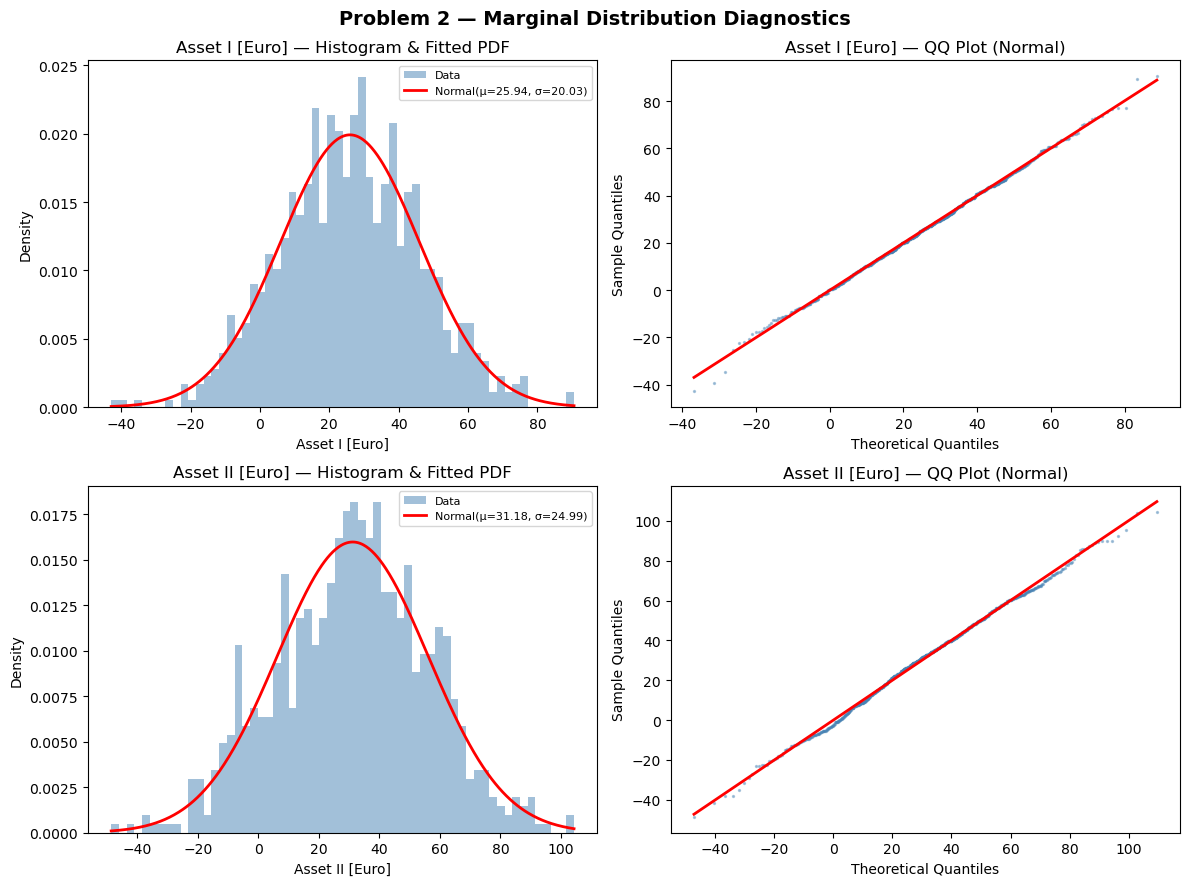

Saved: prob2_marginals.png


In [7]:
# Section 3: Visual Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Problem 2 — Marginal Distribution Diagnostics", fontsize=14, fontweight='bold')

for i, (X, dist_type, params, name) in enumerate(
        [(X1, dist1, params1, "Asset I [Euro]"), (X2, dist2, params2, "Asset II [Euro]")]):

    ax_hist = axes[i, 0]
    ax_qq   = axes[i, 1]

    # Histogram + fitted PDF
    x_range = np.linspace(X.min(), X.max(), 500)
    if dist_type == 'normal':
        mu, sigma = params
        pdf_vals  = norm.pdf(x_range, mu, sigma)
        label     = f"Normal(μ={mu:.2f}, σ={sigma:.2f})"
    else:
        mu_ln, sig_ln = params
        pdf_vals  = lognorm.pdf(x_range, sig_ln, 0, np.exp(mu_ln))
        label     = f"Lognormal(μ_ln={mu_ln:.2f}, σ_ln={sig_ln:.2f})"

    ax_hist.hist(X, bins=60, density=True, alpha=0.5, color='steelblue', label='Data')
    ax_hist.plot(x_range, pdf_vals, 'r-', lw=2, label=label)
    ax_hist.set_title(f"{name} — Histogram & Fitted PDF")
    ax_hist.set_xlabel(name); ax_hist.set_ylabel("Density")
    ax_hist.legend(fontsize=8)

    # QQ plot
    (osm, osr), (slope, intercept, r) = stats.probplot(X, dist='norm' if dist_type=='normal'
                                                        else 'lognorm',
                                                        sparams=params if dist_type=='normal'
                                                        else (params[1],),
                                                        plot=None)
    ax_qq.scatter(osm, osr, s=2, alpha=0.4, color='steelblue')
    line_x = np.array([osm.min(), osm.max()])
    ax_qq.plot(line_x, slope*line_x + intercept, 'r-', lw=2)
    ax_qq.set_title(f"{name} — QQ Plot ({dist_type.capitalize()})")
    ax_qq.set_xlabel("Theoretical Quantiles"); ax_qq.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.savefig("prob2_marginals.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: prob2_marginals.png")

<h1>Copula Parameter Estimation</h1>

In [8]:

# Gaussian Copula: rho from standard normal space 
z1 = norm.ppf(u1)   # Phi^{-1}(u1)
z2 = norm.ppf(u2)   # Phi^{-1}(u2)

rho_hat = np.corrcoef(z1, z2)[0, 1]
print(f"\nGaussian Copula: rho_hat = {rho_hat:.6f}")

# Clayton Copula: theta from Kendall's tau 
tau, p_value = kendalltau(X1, X2)
theta_hat = 2 * tau / (1 - tau)
print(f"Kendall's tau   = {tau:.6f}  (p={p_value:.2e})")
print(f"Clayton Copula: theta_hat = {theta_hat:.6f}")

if theta_hat <= 0:
    print("  WARNING: theta <= 0; Clayton copula requires theta > 0.")
    print("  This suggests the data may have negative or weak lower-tail dependence.")
    print("  Gaussian copula is likely the better model here.")





Gaussian Copula: rho_hat = 0.369410
Kendall's tau   = 0.238461  (p=5.82e-24)
Clayton Copula: theta_hat = 0.626259


<h1> Copula Density Functions & Log-Likelihood</h1>

In [9]:
def gaussian_copula_density(u1, u2, rho):
    """
    Gaussian copula density:
      c(u1,u2) = 1/sqrt(1-rho^2) * exp(
        -[rho^2*(z1^2+z2^2) - 2*rho*z1*z2] / [2*(1-rho^2)]
      )
    where z1=Phi^{-1}(u1), z2=Phi^{-1}(u2)
    """
    z1 = norm.ppf(u1)
    z2 = norm.ppf(u2)
    r2 = rho**2
    log_c = (-0.5 * np.log(1 - r2)
             - (r2*(z1**2 + z2**2) - 2*rho*z1*z2) / (2*(1 - r2)))
    return np.exp(log_c)

def clayton_copula_density(u1, u2, theta):
    """
    Clayton copula density:
      c(u1,u2) = (1+theta)*(u1*u2)^{-(1+theta)} * (u1^{-theta}+u2^{-theta}-1)^{-(1+2*theta)/theta}
    """
    term1 = (1 + theta) * (u1 * u2)**(-(1 + theta))
    term2 = (u1**(-theta) + u2**(-theta) - 1)**(-(1 + 2*theta)/theta)
    return term1 * term2

# Log-likelihoods
def log_likelihood(density_fn, u1, u2, **kwargs):
    c_vals = density_fn(u1, u2, **kwargs)
    c_vals = np.clip(c_vals, 1e-300, None)  
    return np.sum(np.log(c_vals))

ll_gaussian = log_likelihood(gaussian_copula_density, u1, u2, rho=rho_hat)
print(f"\nLog-Likelihood (Gaussian copula):  {ll_gaussian:.4f}")

if theta_hat > 0:
    ll_clayton = log_likelihood(clayton_copula_density, u1, u2, theta=theta_hat)
    print(f"Log-Likelihood (Clayton copula):   {ll_clayton:.4f}")
    best = "Gaussian" if ll_gaussian >= ll_clayton else "Clayton"
    print(f"\n→ Best copula for Problem 2: {best}")
else:
    ll_clayton = None
    print("Clayton copula not applicable (theta <= 0). Gaussian copula selected.")
    best = "Gaussian"


Log-Likelihood (Gaussian copula):  58.6879
Log-Likelihood (Clayton copula):   83.5991

→ Best copula for Problem 2: Clayton


<h1>Monte Carlo Simulation of Y = X₁ + X₂</h1>

#### Monte Carlo Simulation of $Y = X_1 + X_2$

In this section, Monte Carlo simulation is used to study the total portfolio cash flow:

$$
Y = X_1 + X_2
$$

The goal is to generate many possible values of $X_1$ and $X_2$ from the fitted joint probabilistic models, and then compute the corresponding values of $Y$.

Two dependence models are simulated:

* **Model I:** Gaussian copula + Normal marginals
* **Model II:** Clayton copula + Normal marginals

The simulation begins by generating random samples in the unit square. These samples represent probabilities between 0 and 1.  
They are then transformed back to the original asset scale using the marginal inverse CDF, also called the quantile function:

$$
X_1 = F_{X_1}^{-1}(v_1)
$$

$$
X_2 = F_{X_2}^{-1}(v_2)
$$

After obtaining simulated values of $X_1$ and $X_2$, the portfolio cash flow is computed as:

$$
Y_i = X_{1,i} + X_{2,i}
$$

This simulation allows us to estimate the distribution of $Y$, including the average cash flow and the lower-tail loss quantile.  
The lower tail is especially important because the company wants to understand rare but severe loss events.

In [10]:
#  — Monte Carlo Simulation of Y = X1 + X2
# The marginal quantile function (inverse CDF) maps uniform samples back to
# the original Euro scale.  Two models are simulated:
#   Model I  — Gaussian copula + Normal marginals
#   Model II — Clayton copula  + Normal marginals
 
N_sim = 500_000     # large enough for stable 1e-3 quantile estimation
rng   = np.random.default_rng(seed=42)
 
 
# Gaussian copula sampling
def sample_gaussian_copula(rho, N, rng):
    """
    Draw N samples (u1, u2) from the Gaussian copula with parameter rho.
    Method: sample bivariate normal Z ~ N(0, R0), then apply Phi.
    """
    cov = np.array([[1.0, rho], [rho, 1.0]])
    Z   = rng.multivariate_normal([0.0, 0.0], cov, size=N)
    return norm.cdf(Z[:, 0]), norm.cdf(Z[:, 1])
 
 
# Clayton copula sampling (conditional inversion, Marshall-Olkin method)
def sample_clayton_copula(theta, N, rng):
    """
    Draw N samples (u1, u2) from the Clayton copula with parameter theta > 0.
 
    Algorithm (exact conditional inversion):
      1. u1 ~ Uniform(0, 1)
      2. t  ~ Uniform(0, 1)   [conditional quantile level]
      3. Solve F(u2 | u1) = t  for u2, where
            F(u2|u1) = dC^Cly/du1 = u1^{-(theta+1)} * (u1^{-theta}+u2^{-theta}-1)^{-(theta+1)/theta}
         Inversion gives:
            u2 = [(t * u1^{theta+1})^{-theta/(theta+1)} - u1^{-theta} + 1]^{-1/theta}
 
    This guarantees u1 ~ Uniform and u2 ~ Uniform marginally.
    """
    u1    = rng.uniform(0.0, 1.0, N)
    t     = rng.uniform(0.0, 1.0, N)
    inner = np.clip(
        (t * u1**(theta + 1.0))**(-theta / (theta + 1.0)) - u1**(-theta) + 1.0,
        1e-15, None
    )
    u2 = np.clip(inner**(-1.0 / theta), 1e-8, 1 - 1e-8)
    return u1, u2
 
 
def invert_marginal(u, F_inv):
    """Back-transform uniform samples to the original scale using the quantile function."""
    return F_inv(u)
 
 
#  Model I: Gaussian Copula 
u1_ga, u2_ga = sample_gaussian_copula(rho_hat, N_sim, rng)
X1_sim_ga    = invert_marginal(u1_ga, F1_inv)
X2_sim_ga    = invert_marginal(u2_ga, F2_inv)
Y_ga         = X1_sim_ga + X2_sim_ga
 
# Model II: Clayton Copula 
if theta_hat > 0:
    u1_cl, u2_cl = sample_clayton_copula(theta_hat, N_sim, rng)
    X1_sim_cl    = invert_marginal(u1_cl, F1_inv)
    X2_sim_cl    = invert_marginal(u2_cl, F2_inv)
    Y_cl         = X1_sim_cl + X2_sim_cl
else:
    Y_cl = Y_ga.copy()   
 
# Expected cash flow and capital buffer quantile 
risk_level = 1e-3
 
E_Y_ga = np.mean(Y_ga)
q_ga   = np.quantile(Y_ga, risk_level)
 
E_Y_cl = np.mean(Y_cl)
q_cl   = np.quantile(Y_cl, risk_level)
 
# Theoretical E[Y] by linearity of expectation (copula-independent)
E_Y_theoretical = params1[0] + params2[0]   # mu1 + mu2 for Normal marginals
 
print(f"\n{'='*54}")
print(f"  Theoretical E[Y] = mu1 + mu2 = {E_Y_theoretical:.4f} EUR")
print(f"{'='*54}")
print(f"  Model I  (Gaussian Copula)")
print(f"    E[Y]              = {E_Y_ga:.4f} EUR")
print(f"    F^{{-1}}_Y(1e-3)   = {q_ga:.4f} EUR")
print(f"\n  Model II (Clayton Copula)")
print(f"    E[Y]              = {E_Y_cl:.4f} EUR")
print(f"    F^{{-1}}_Y(1e-3)   = {q_cl:.4f} EUR")
print(f"\n  Difference in E[Y]        : {abs(E_Y_ga - E_Y_cl):.4f} EUR  (should be ~0)")
print(f"  Difference in 1e-3 quantile: {abs(q_ga - q_cl):.4f} EUR")
print(f"{'='*54}")


  Theoretical E[Y] = mu1 + mu2 = 57.1273 EUR
  Model I  (Gaussian Copula)
    E[Y]              = 57.1799 EUR
    F^{-1}_Y(1e-3)   = -57.8021 EUR

  Model II (Clayton Copula)
    E[Y]              = 57.1207 EUR
    F^{-1}_Y(1e-3)   = -73.2629 EUR

  Difference in E[Y]        : 0.0593 EUR  (should be ~0)
  Difference in 1e-3 quantile: 15.4608 EUR


<h1>Final Plots: CDF of Y in Semi-Log Scale</h1>

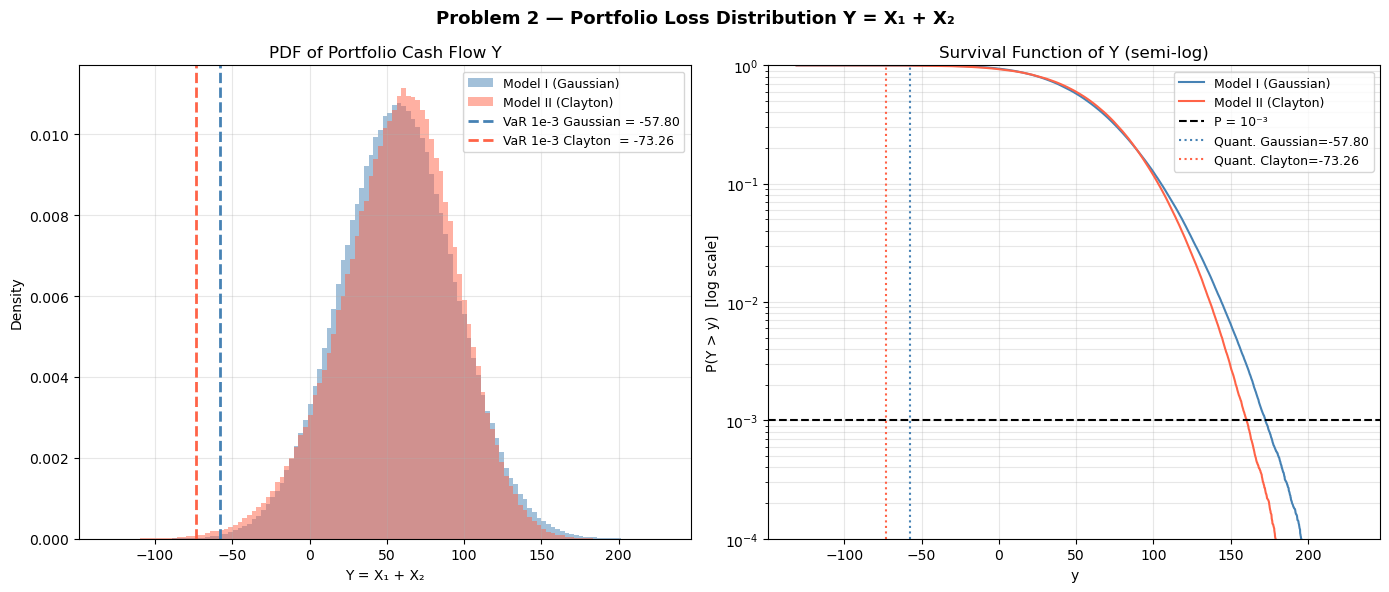

Saved: prob2_portfolio_risk.png


In [11]:
# Final Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Problem 2 — Portfolio Loss Distribution Y = X₁ + X₂",
             fontsize=13, fontweight='bold')

# Plot 1: PDF of Y (both models) 
ax = axes[0]
bins = np.linspace(min(Y_ga.min(), Y_cl.min()),
                   max(Y_ga.max(), Y_cl.max()), 120)
ax.hist(Y_ga, bins=bins, density=True, alpha=0.5, color='steelblue', label='Model I (Gaussian)')
ax.hist(Y_cl, bins=bins, density=True, alpha=0.5, color='tomato',    label='Model II (Clayton)')
ax.axvline(q_ga, color='steelblue', lw=2, ls='--', label=f'VaR 1e-3 Gaussian = {q_ga:.2f}')
ax.axvline(q_cl, color='tomato',    lw=2, ls='--', label=f'VaR 1e-3 Clayton  = {q_cl:.2f}')
ax.set_xlabel("Y = X₁ + X₂")
ax.set_ylabel("Density")
ax.set_title("PDF of Portfolio Cash Flow Y")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: CDF of Y in semi-log scale (log on probability axis) 
ax2 = axes[1]

# Sort and compute empirical CDF
for Y_vals, color, label in [
        (Y_ga, 'steelblue', 'Model I (Gaussian)'),
        (Y_cl, 'tomato',    'Model II (Clayton)')]:
    y_sorted = np.sort(Y_vals)
    p        = np.linspace(1/N_sim, 1 - 1/N_sim, N_sim)
    ax2.semilogy(y_sorted, 1 - p, color=color, lw=1.5, label=label)

ax2.axhline(1e-3, color='k', ls='--', lw=1.5, label='P = 10⁻³')
ax2.axvline(q_ga, color='steelblue', ls=':', lw=1.5, label=f'Quant. Gaussian={q_ga:.2f}')
ax2.axvline(q_cl, color='tomato',    ls=':', lw=1.5, label=f'Quant. Clayton={q_cl:.2f}')
ax2.set_xlabel("y")
ax2.set_ylabel("P(Y > y)  [log scale]")
ax2.set_title("Survival Function of Y (semi-log)")
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)
ax2.set_ylim([1e-4, 1])

plt.tight_layout()
plt.savefig("prob2_portfolio_risk.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: prob2_portfolio_risk.png")